# 

# Generalization Datasets

- Classificaiton
  - tox21
  - toxcast
  - muv
  - pcba
- Regression
  - hopv - homo, lumo
  - zinc15 - logp
  - freesolv - hydration free energy
- Rxn
  - open reaction database
- M2T
  - hanbum's dataset
- T2M
  - hanbum's dataset

# Check dataset availability

In [2]:
import torch
from ogb.utils.features import (allowable_features, atom_to_feature_vector,
 bond_to_feature_vector, atom_feature_vector_to_dict, bond_feature_vector_to_dict) 
from torch_geometric.data import Data

def mol2graph(mol):
    """
    Converts SMILES string to graph Data object
    :input: SMILES string (str)
    :return: graph object
    """
    # atoms
    atom_features_list = []
    for atom in mol.GetAtoms():
        atom_features_list.append(atom_to_feature_vector(atom))
    x = np.array(atom_features_list, dtype = np.int64)

    # bonds
    num_bond_features = 3  # bond type, bond stereo, is_conjugated
    if len(mol.GetBonds()) > 0: # mol has bonds
        edges_list = []
        edge_features_list = []
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()

            edge_feature = bond_to_feature_vector(bond)

            # add edges in both directions
            edges_list.append((i, j))
            edge_features_list.append(edge_feature)
            edges_list.append((j, i))
            edge_features_list.append(edge_feature)

        # data.edge_index: Graph connectivity in COO format with shape [2, num_edges]
        edge_index = np.array(edges_list, dtype = np.int64).T

        # data.edge_attr: Edge feature matrix with shape [num_edges, num_edge_features]
        edge_attr = np.array(edge_features_list, dtype = np.int64)

    else:   # mol has no bonds
        edge_index = np.empty((2, 0), dtype = np.int64)
        edge_attr = np.empty((0, num_bond_features), dtype = np.int64)

    graph = dict()
    graph['edge_index'] = edge_index
    graph['edge_feat'] = edge_attr
    graph['node_feat'] = x
    graph['num_nodes'] = len(x)

    return graph 

def graph2data(graph):
    x = torch.from_numpy(graph["node_feat"])
    edge_index = torch.from_numpy(
        graph["edge_index"],
    )
    edge_attr = torch.from_numpy(graph["edge_feat"])
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data

/miniconda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import deepchem as dc
task_name = "hopv"
base_path = f"/text-mol/dataset/{task_name}"

tasks, hopv_dataset, transformers = dc.molnet.load_hopv(
                featurizer="Raw",
                splitter="scaffold",
                save_dir=base_path,
                data_dir=base_path,
                reload=True,
            )

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [4]:
tasks

['HOMO',
 'LUMO',
 'electrochemical_gap',
 'optical_gap',
 'PCE',
 'V_OC',
 'J_SC',
 'fill_factor']

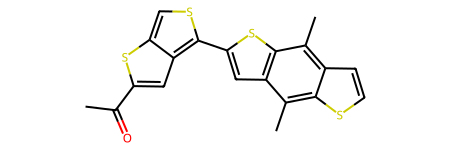

In [5]:
hopv_dataset[0].X[0]

In [6]:
hopv_dataset[0].y[0]

array([-0.63297292, -0.7128188 ,  0.57725793,  0.66159317,  0.36454062,
        0.24256758,  0.17700304,  0.68293004])

In [7]:
import instructions_smol
import model.added_tokens as added_tokens
import numpy as np

# class arugments
X = hopv_dataset[0].X
y = hopv_dataset[0].y
task_name = "hopv_homo"
instruction_templates = instructions_smol.qm9_homo

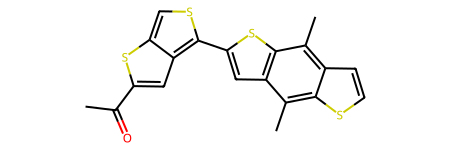

In [8]:
X[0]

In [9]:
from rdkit import Chem
import selfies as sf
from download_dataset import wrap_label
from tqdm import tqdm

def get_dataset(
        list_mol, list_label, task, subtask_idx, instruction_templates,
):
    instruction = np.random.choice(instruction_templates).item()
    list_mol = X[:]
    list_label = y[:, subtask_idx]
    iter_bar = tqdm(range(len(list_mol)))
    data_list_dict = []
    for i in iter_bar:
        mol = list_mol[i]
        label = list_label[i]

        smiles = Chem.MolToSmiles(mol)
        selfies = sf.encoder(smiles)
        input_mol_string = added_tokens.SELFIES[0] + selfies + added_tokens.SELFIES[1]

        label = wrap_label(label, task=task_name)
        graph = mol2graph(mol)

        data ={
            "task": task,
            "x": graph.x,
            "edge_index": data_instance["edge_index"],
            "edge_attr": data_instance["edge_attr"],
            "additional_x": data_instance["x"],
            "additional_edge_index": data_instance["edge_index"],
            "additional_edge_attr": data_instance["edge_attr"],
            "prompt_text": formatted_prompt_text,
            "target_text": formatted_target_text,
        }

In [14]:
y[:, 0]

array([-0.63297292, -0.68252586, -0.60406704, -0.52354351, -0.59167881,
       -0.63297292, -0.59167881, -0.71143174, -0.74033762, -0.58341998,
       -0.57103175, -0.55864351, -0.55864351, -0.6247141 , -0.60406704,
       -0.55864351, -0.50083175, -0.6247141 , -0.52147881, -0.60406704,
       -0.82911997,  1.52257992, -0.77061997, -0.74446703, -0.64949057,
       -0.67013763, -0.59993763, -0.64123174, -0.70730233, -0.76511409,
       -0.59993763, -0.74859645,  1.52257992, -0.65637292, -0.72381998,
       -0.70730233, -0.65499645, -0.93441997, -0.74033762, -0.58754939,
       -0.57929057, -0.6618788 ,  1.52257992,  1.52257992,  1.52257992,
        1.52257992,  1.52257992,  1.52257992,  1.52257992,  1.52257992,
        1.52257992,  1.52257992,  1.52257992, -0.59993763,  1.52257992,
       -0.55864351, -0.58754939,  1.52257992,  1.52257992, -1.07894937,
        1.52257992,  1.52257992,  1.52257992, -0.68252586, -0.60406704,
       -0.6618788 , -0.69078468, -0.66600821, -0.66600821, -0.67

In [11]:
from rdkit import Chem
import selfies as sf
from download_dataset import wrap_label

data_idx = 0
subtask_idx = 0

instruction = np.random.choice(instruction_templates).item()
mol = X[data_idx]
smiles = Chem.MolToSmiles(mol)
selfies = sf.encoder(smiles)
input_mol_string = added_tokens.SELFIES[0] + selfies + added_tokens.SELFIES[1]

label = y[data_idx][subtask_idx]
label = wrap_label(label, task=task_name)
graph = mol2graph(mol)

graph, label, input_mol_string, instruction


({'edge_index': array([[ 0, 23, 23, 16, 23,  2,  2, 19, 19,  7,  7,  4,  4, 18, 18, 11,
          11,  8,  8, 24, 24, 20, 20, 14, 14,  1,  1,  3,  1, 10, 10,  9,
          10, 22, 22, 15, 15,  6,  6,  5,  5, 17, 17, 12, 12, 21,  4, 13,
          13,  2,  8,  7,  3, 24, 17, 22, 12, 14],
         [23,  0, 16, 23,  2, 23, 19,  2,  7, 19,  4,  7, 18,  4, 11, 18,
           8, 11, 24,  8, 20, 24, 14, 20,  1, 14,  3,  1, 10,  1,  9, 10,
          22, 10, 15, 22,  6, 15,  5,  6, 17,  5, 12, 17, 21, 12, 13,  4,
           2, 13,  7,  8, 24,  3, 22, 17, 14, 12]]),
  'edge_feat': array([[0, 0, 0],
         [0, 0, 0],
         [1, 0, 1],
         [1, 0, 1],
         [0, 0, 1],
         [0, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [0, 0, 1],
         [0, 0, 1],
         [3, 0, 1],
     

In [12]:
graph, label, input_mol_string, instruction

({'edge_index': array([[ 0, 23, 23, 16, 23,  2,  2, 19, 19,  7,  7,  4,  4, 18, 18, 11,
          11,  8,  8, 24, 24, 20, 20, 14, 14,  1,  1,  3,  1, 10, 10,  9,
          10, 22, 22, 15, 15,  6,  6,  5,  5, 17, 17, 12, 12, 21,  4, 13,
          13,  2,  8,  7,  3, 24, 17, 22, 12, 14],
         [23,  0, 16, 23,  2, 23, 19,  2,  7, 19,  4,  7, 18,  4, 11, 18,
           8, 11, 24,  8, 20, 24, 14, 20,  1, 14,  3,  1, 10,  1,  9, 10,
          22, 10, 15, 22,  6, 15,  5,  6, 17,  5, 12, 17, 21, 12, 13,  4,
           2, 13,  7,  8, 24,  3, 22, 17, 14, 12]]),
  'edge_feat': array([[0, 0, 0],
         [0, 0, 0],
         [1, 0, 1],
         [1, 0, 1],
         [0, 0, 1],
         [0, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [3, 0, 1],
         [0, 0, 1],
         [0, 0, 1],
         [3, 0, 1],
     